In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

def create_images_list(path):
    images = sorted(os.listdir(path))
    full_path = [os.path.join(path, i) for i in images]
    return full_path

def images_from_masks(images_path, masks_path):
    images = sorted(os.listdir(images_path))
    masks = sorted(os.listdir(masks_path))
    image_paths = [os.path.join(images_path, img) for img in images]
    mask_paths = [os.path.join(masks_path, mask) for mask in masks]
    return image_paths, mask_paths

images_dir = '/content/drive/My Drive/Unet/preimages'
masks_dir = '/content/drive/My Drive/Unet/masks1'

# Rutas de imagenes y máscaras
images, masks = images_from_masks(images_dir, masks_dir)

full_data = pd.DataFrame({'image': images, 'mask': masks})
full_data = shuffle(full_data, random_state=42).reset_index(drop=True)

#Division de datos
X_train, X_test, y_train, y_test = train_test_split(full_data['image'], full_data['mask'], test_size=0.2, random_state=42)


In [ ]:
print("train images: ", X_train.shape[0])
print("test images: ", X_test.shape[0])

train images:  547
test images:  137


In [ ]:
import tensorflow as tf

#Tamaño de la imagen deseado y tamaño del bach para el entrenamiento y la prueba
IMG_SIZE = (256, 256)
BATCH_SIZE = 32


def img_preprocessing(image_path, mask_path):

    img = tf.io.read_file(image_path)
    img = tf.io.decode_png(img, channels=1)  #
    img = tf.image.resize(img, [256, 256])
    img = img / 255.0

    # Decodificación de la mascara
    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256])
    mask = mask / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask


train_loader = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_loader.map(img_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_loader = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_loader.map(img_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras.layers import Layer, SeparableConv2D, MaxPooling2D, Dropout, UpSampling2D, concatenate
from tensorflow.keras import Model

class EncoderBlock(Layer):
    def __init__(self, filters, kernel_size=(3, 3), rate=0.1, pooling=True, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.pooling = pooling
        self.conv1 = SeparableConv2D(filters, kernel_size, activation='relu', padding='same', kernel_initializer='he_normal')
        self.conv2 = SeparableConv2D(filters, kernel_size, activation='relu', padding='same', kernel_initializer='he_normal')
        self.drop = Dropout(rate)
        self.pool = MaxPooling2D() if pooling else None

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.drop(x)
        x = self.conv2(x)
        if self.pooling:
            p = self.pool(x)
            return p, x
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "pooling": self.pooling,
            "drop_rate": self.drop.rate,
            "filters": self.conv1.filters,
            "kernel_size": self.conv1.kernel_size
        })
        return config

class DecoderBlock(Layer):
    def __init__(self, filters, kernel_size=(3, 3), rate=0.1, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.up = UpSampling2D()
        self.conv_block = EncoderBlock(filters, kernel_size, rate, pooling=False)

    def call(self, inputs):
        input_tensor, skip_tensor = inputs
        x = self.up(input_tensor)
        x = concatenate([x, skip_tensor])
        x = self.conv_block(x)
        return x


In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.)

def dice_coef_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def jaccard_index(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    sum_union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + 1e-5) / (sum_union + 1e-5)


In [ ]:
from tensorflow.keras.layers import Layer, Input, Conv2D, MaxPooling2D, Dropout, SeparableConv2D
from tensorflow.keras import Model

class EncoderBlock(Layer):
    def __init__(self, filters, kernel_size, rate, pooling=True, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.pooling = pooling
        self.conv1 = SeparableConv2D(filters, kernel_size, activation='relu', padding='same', kernel_initializer='he_normal')
        self.conv2 = SeparableConv2D(filters, kernel_size, activation='relu', padding='same', kernel_initializer='he_normal')
        self.drop = Dropout(rate)
        self.pool = MaxPooling2D() if pooling else None

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.drop(x)
        x = self.conv2(x)
        if self.pooling:
            p = self.pool(x)
            return p, x
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "pooling": self.pooling
        })
        return config



In [ ]:
from tensorflow.keras.layers import UpSampling2D, concatenate

class DecoderBlock(Layer):
    def __init__(self, filters, kernel_size, rate, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.up = UpSampling2D()
        self.conv_block = EncoderBlock(filters, kernel_size, rate, pooling=False)

    def call(self, inputs):
        input_tensor, skip_tensor = inputs
        x = self.up(input_tensor)
        x = concatenate([x, skip_tensor])
        x = self.conv_block(x)
        return x


In [ ]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

#Strategia de distribucion
strategy = tf.distribute.get_strategy()

with strategy.scope():
    inp = Input(shape=(256, 256, 1))
    p1, c1 = EncoderBlock(32, 2, 0.1, name='Encoder1')(inp)
    p2, c2 = EncoderBlock(64, 2, 0.1, name='Encoder2')(p1)
    p3, c3 = EncoderBlock(128, 2, 0.2, name='Encoder3')(p2)
    p4, c4 = EncoderBlock(256, 2, 0.2, name='Encoder4')(p3)

    encoding = EncoderBlock(512, 2, 0.3, pooling=False, name='Encoding')(p4)

    d1 = DecoderBlock(256, 2, 0.2, name='Decoder1')([encoding, c4])
    d2 = DecoderBlock(128, 2, 0.2, name='Decoder2')([d1, c3])
    d3 = DecoderBlock(64, 2, 0.1, name='Decoder3')([d2, c2])
    d4 = DecoderBlock(32, 2, 0.1, name='Decoder4')([d3, c1])

    out = Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(d4)
    model = Model(inputs=inp, outputs=out)

    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])



In [ ]:
hist = model.fit(
    train_dataset,
    epochs=80,
    validation_data=test_dataset,
)

Epoch 1/80
18/18 [==============================] - 820s 9s/step - loss: 0.6810 - accuracy: 0.7460 - val_loss: 0.6624 - val_accuracy: 0.7548
Epoch 2/80
18/18 [==============================] - 85s 2s/step - loss: 0.6435 - accuracy: 0.7461 - val_loss: 0.6076 - val_accuracy: 0.7548
Epoch 3/80
18/18 [==============================] - 80s 2s/step - loss: 0.5819 - accuracy: 0.7461 - val_loss: 0.5578 - val_accuracy: 0.7548
Epoch 4/80
18/18 [==============================] - 71s 1s/step - loss: 0.5667 - accuracy: 0.7461 - val_loss: 0.5544 - val_accuracy: 0.7548
Epoch 5/80
18/18 [==============================] - 74s 1s/step - loss: 0.5635 - accuracy: 0.7461 - val_loss: 0.5510 - val_accuracy: 0.7548
Epoch 6/80
18/18 [==============================] - 80s 2s/step - loss: 0.5611 - accuracy: 0.7461 - val_loss: 0.5473 - val_accuracy: 0.7548
Epoch 7/80
18/18 [==============================] - 84s 2s/step - loss: 0.5564 - accuracy: 0.7461 - val_loss: 0.5411 - val_accuracy: 0.7548
Epoch 8/80
18/18 [=

5/5 [==============================] - 14s 2s/step - loss: 0.2726 - accuracy: 0.8809
Evaluación completa:
Perdida en el Test: 0.2725680470466614, Precisión en el Test: 0.8809428215026855
1/1 [==============================] - 0s 346ms/step


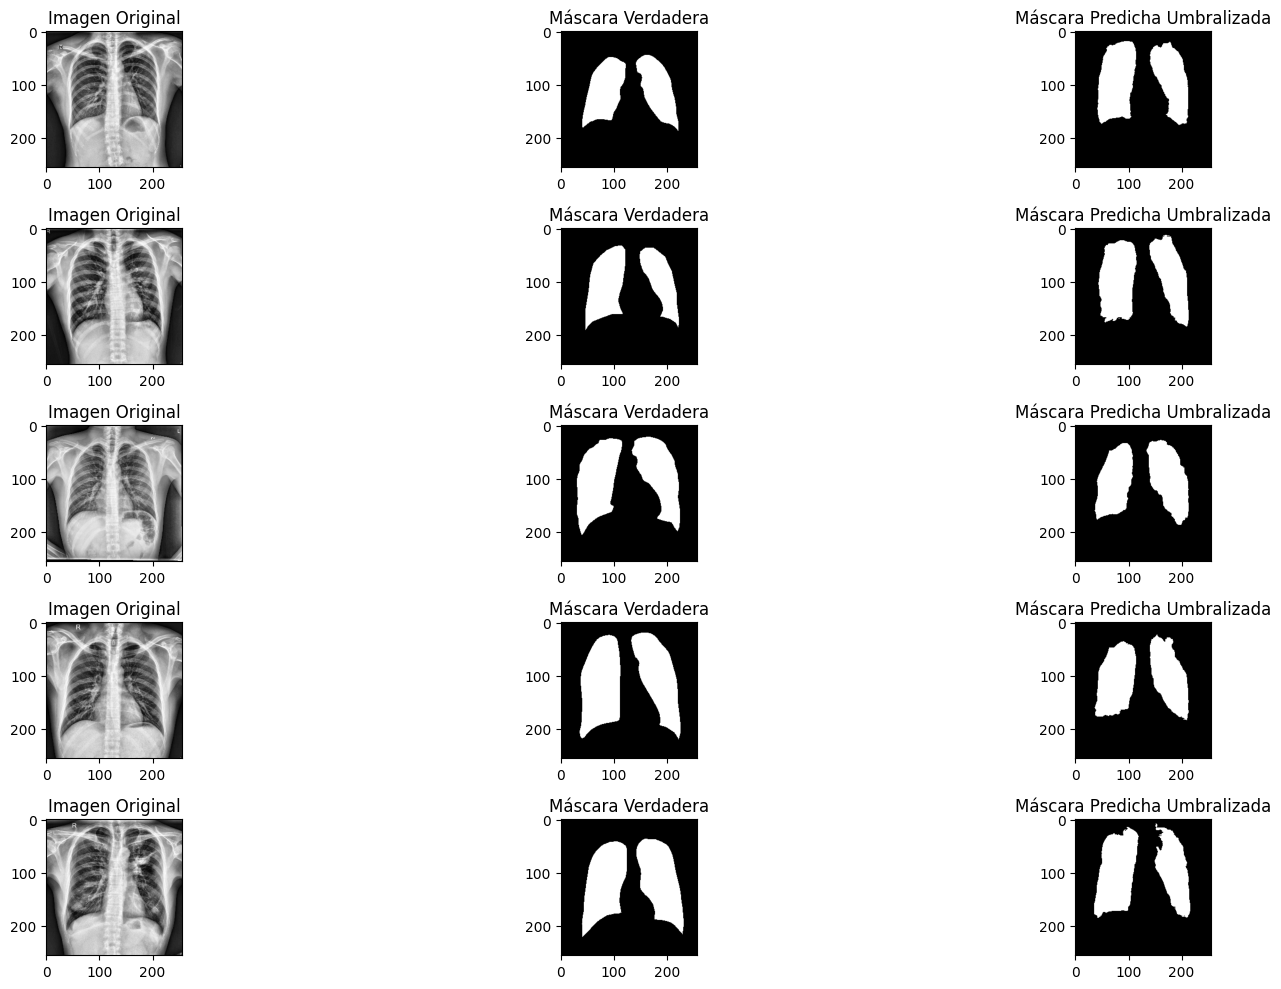

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluación
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Evaluación completa:")
print(f"Perdida en el Test: {test_loss}, Precisión en el Test: {test_accuracy}")

# Visualización de resultados con umbral
def advanced_plot_predictions(dataset, num_images=5, threshold=0.5):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_thresholded = (preds >= threshold).astype(np.float32)

        fig, axes = plt.subplots(num_images, 3, figsize=(18, 10))
        for i in range(num_images):
            axes[i, 0].imshow(images[i, :, :, 0], cmap='gray')
            axes[i, 0].set_title('Imagen Original')
            axes[i, 1].imshow(masks[i, :, :, 0], cmap='gray')
            axes[i, 1].set_title('Máscara Verdadera')
            axes[i, 2].imshow(preds_thresholded[i, :, :, 0], cmap='gray')
            axes[i, 2].set_title('Máscara Predicha Umbralizada')
        plt.tight_layout()
        plt.show()

# Llamada a la función con el dataset de test
advanced_plot_predictions(test_dataset)

def evaluate_metrics(dataset, model, threshold=0.5):
    dice_scores = []
    iou_scores = []

    for images, true_masks in dataset:
        preds = model.predict(images)
        preds_thresholded = (preds >= threshold).astype(np.float32)

        for i in range(len(true_masks)):
            dice_score = dice_coefficient(true_masks[i], preds_thresholded[i])
            iou_score = iou(true_masks[i], preds_thresholded[i])

            dice_scores.append(dice_score)
            iou_scores.append(iou_score)

    # Calcula y devuelve el promedio de las métricas
    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)
    return mean_dice, mean_iou
def evaluate_metrics(dataset, model, threshold=0.5):
    dice_scores = []
    iou_scores = []

    for images, true_masks in dataset:
        preds = model.predict(images)
        preds_thresholded = (preds >= threshold).astype(np.float32)

        for i in range(len(true_masks)):
            dice_score = dice_coefficient(true_masks[i], preds_thresholded[i])
            iou_score = iou(true_masks[i], preds_thresholded[i])

            dice_scores.append(dice_score)
            iou_scores.append(iou_score)

    # Calcula y devuelve el promedio de las métricas
    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)
    return mean_dice, mean_iou


5/5 [==============================] - 15s 3s/step - loss: 0.2726 - accuracy: 0.8809
Pérdida en el conjunto de prueba: 0.2725680470466614
Exactitud en el conjunto de prueba: 0.8809428215026855


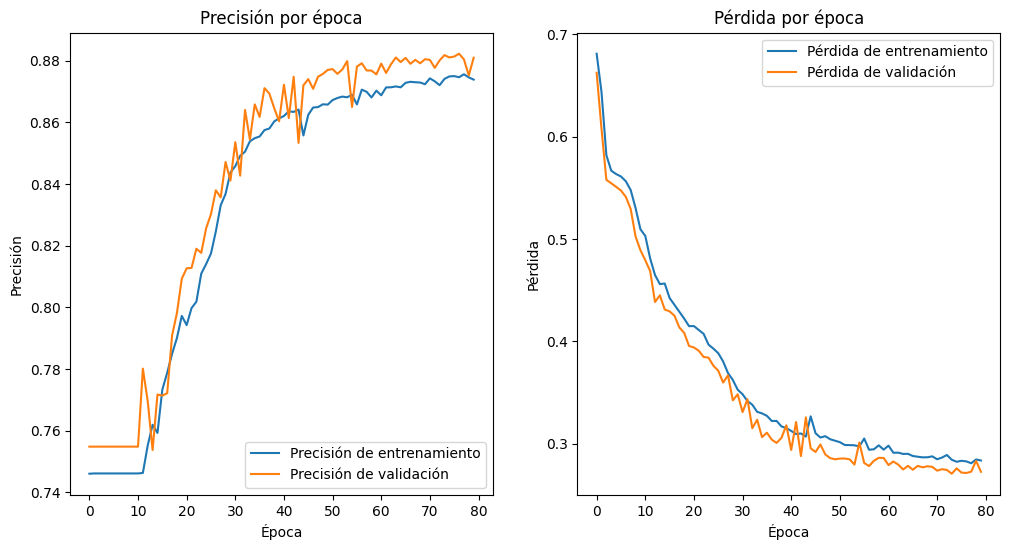

In [ ]:
import numpy as np

def calculate_metrics(dice_scores, iou_scores):
    # Calcula el promedio de las métricas
    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)
    # Imprime los resultados
    print("Promedio de DICE Score:", mean_dice)
    print("Promedio de IOU Score:", mean_iou)
# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Pérdida en el conjunto de prueba:", test_loss)
print("Exactitud en el conjunto de prueba:", test_accuracy)

import matplotlib.pyplot as plt

# Graficar la precisión y la pérdida a lo largo de las épocas
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(hist.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Pérdida de entrenamiento')
plt.plot(hist.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()


In [ ]:
dice_scores = [0.9, 0.85, 0.87]
iou_scores = [0.8, 0.75, 0.78]

calculate_metrics(dice_scores, iou_scores)
def calculate_metrics(dice_scores, iou_scores):
    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)
    with open('output.txt', 'w') as f:
        f.write(f"Promedio de DICE Score: {mean_dice}\n")
        f.write(f"Promedio de IOU Score: {mean_iou}\n")

calculate_metrics(dice_scores, iou_scores)


Promedio de DICE Score: 0.8733333333333334
Promedio de IOU Score: 0.7766666666666667
